## Memo Pilot Test

In [348]:
# Mount Google Drive and setup
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import json
import pickle
import warnings
import os
import re
from collections import Counter
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Define paths
data_dir = '/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_2/files/Kaggle/data'
pilot_dir = f'{data_dir}/pilot_test'
os.makedirs(pilot_dir, exist_ok=True)

# Load arXiv metadata with larger sample and random sampling
data_path = f'{data_dir}/arxiv-metadata-oai-snapshot.json'

print("\nLoading arXiv data with random sampling...")
print("Scanning dataset to collect papers...")

def extract_year(paper):
    """Extract publication year from arXiv paper metadata"""
    try:
        # Try update_date first (format: "2007-05-23")
        if 'update_date' in paper and paper['update_date']:
            year = int(paper['update_date'][:4])
            if 2010 <= year <= 2024:
                return year
    except:
        pass

    try:
        # Try versions (format: "Mon, 2 Apr 2007 19:18:42 GMT")
        if 'versions' in paper and paper['versions']:
            created = paper['versions'][0].get('created', '')
            # Extract year from end of string
            match = re.search(r'(\d{4})', created)
            if match:
                year = int(match.group(1))
                if 2010 <= year <= 2024:
                    return year
    except:
        pass

    return None

# Collect papers with valid years
all_papers = []
scan_limit = 2000000  # Scan up to 2M papers

with open(data_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= scan_limit:
            break
        if i % 500000 == 0:
            print(f"  Scanned {i:,} papers, collected {len(all_papers):,}...")

        try:
            paper = json.loads(line)
            year = extract_year(paper)

            if year is not None:
                all_papers.append({
                    'id': paper.get('id', ''),
                    'title': paper.get('title', ''),
                    'abstract': paper.get('abstract', ''),
                    'categories': paper.get('categories', ''),
                    'year': year
                })
        except:
            continue

print(f"\nCollected {len(all_papers):,} papers from 2010-2024")

# Random sampling
np.random.seed(42)
sample_size = 30000  # Larger sample for pilot test
sample_indices = np.random.choice(len(all_papers), min(sample_size, len(all_papers)), replace=False)
sampled_papers = [all_papers[i] for i in sample_indices]

arxiv_pilot = pd.DataFrame(sampled_papers)
print(f"Random sample size: {len(arxiv_pilot):,} papers")

# Check year distribution
print("\nYear distribution in sample:")
year_counts = arxiv_pilot['year'].value_counts().sort_index()
print(year_counts)

# Define time periods for temporal analysis (T1 vs T2)
# T1: 2010-2016 (earlier period)
# T2: 2017-2024 (recent period)
arxiv_pilot['period'] = arxiv_pilot['year'].apply(lambda x: 'T1' if x <= 2016 else 'T2')

print("\nTime period distribution:")
print(arxiv_pilot['period'].value_counts())

# Save for later use
arxiv_pilot.to_pickle(f'{pilot_dir}/arxiv_pilot_data.pkl')
print(f"\nData saved to: {pilot_dir}/arxiv_pilot_data.pkl")

# Preview data
print("\nSample data preview:")
print(arxiv_pilot[['id', 'title', 'year', 'period', 'categories']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading arXiv data with random sampling...
Scanning dataset to collect papers...
  Scanned 0 papers, collected 0...
  Scanned 500,000 papers, collected 392,583...
  Scanned 1,000,000 papers, collected 892,583...
  Scanned 1,500,000 papers, collected 1,392,583...

Collected 1,892,583 papers from 2010-2024
Random sample size: 30,000 papers

Year distribution in sample:
year
2010     684
2011     730
2012     844
2013    1160
2014    1259
2015    3169
2016    1849
2017    1870
2018    2126
2019    2501
2020    2714
2021    2924
2022    3024
2023    3622
2024    1524
Name: count, dtype: int64

Time period distribution:
period
T2    20305
T1     9695
Name: count, dtype: int64

Data saved to: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_2/files/Kaggle/data/pilot_test/arxiv_pilot_data.pkl

Sample data preview:
           id                    

Successfully loaded 30,000 randomly sampled papers from 1.89M arXiv papers (2010-2024), with T1 (2010-2016) containing 9,695 papers and T2 (2017-2024) containing 20,305 papers, providing sufficient temporal contrast for convergence analysis.

In [350]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
from gensim.models import Word2Vec

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)


# Load saved data
arxiv_pilot = pd.read_pickle(f'{pilot_dir}/arxiv_pilot_data.pkl')

# Text preprocessing function (from Module 1 homework)
def preprocess_text(text):
    """Tokenize and normalize text for Word2Vec training"""
    if pd.isna(text) or text is None:
        return []
    text = str(text).lower()
    text = re.sub(r'\$[^$]+\$', ' ', text)  # Remove LaTeX math
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)  # Remove LaTeX commands
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # Keep only letters
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

# Combine title and abstract, then tokenize
print("\nPreprocessing texts...")
arxiv_pilot['combined_text'] = arxiv_pilot['title'] + ' ' + arxiv_pilot['abstract'].fillna('')
arxiv_pilot['tokens'] = arxiv_pilot['combined_text'].apply(preprocess_text)

# Check tokenization results
token_counts = arxiv_pilot['tokens'].apply(len)
print(f"Average tokens per document: {token_counts.mean():.1f}")
print(f"Total documents: {len(arxiv_pilot)}")

# Split data by time period
t1_data = arxiv_pilot[arxiv_pilot['period'] == 'T1']
t2_data = arxiv_pilot[arxiv_pilot['period'] == 'T2']

print(f"\nT1 (2010-2016): {len(t1_data):,} papers")
print(f"T2 (2017-2024): {len(t2_data):,} papers")

# Train Word2Vec model for T1
print("\nTraining Word2Vec model for T1 (2010-2016)...")
t1_tokens = t1_data['tokens'].tolist()
w2v_t1 = Word2Vec(
    sentences=t1_tokens,
    vector_size=100,
    window=10,
    min_count=10,
    workers=4,
    sg=1,  # Skip-gram
    epochs=10
)
print(f"T1 vocabulary size: {len(w2v_t1.wv):,} words")

# Train Word2Vec model for T2
print("\nTraining Word2Vec model for T2 (2017-2024)...")
t2_tokens = t2_data['tokens'].tolist()
w2v_t2 = Word2Vec(
    sentences=t2_tokens,
    vector_size=100,
    window=10,
    min_count=10,
    workers=4,
    sg=1,  # Skip-gram
    epochs=10
)
print(f"T2 vocabulary size: {len(w2v_t2.wv):,} words")

# Save models
w2v_t1.save(f'{pilot_dir}/w2v_t1.model')
w2v_t2.save(f'{pilot_dir}/w2v_t2.model')
print(f"\nModels saved to: {pilot_dir}/")

# Quick sanity check: most similar words
print("Sanity Check: Most similar words to 'network'")


if 'network' in w2v_t1.wv:
    print("\nT1 (2010-2016):")
    for word, sim in w2v_t1.wv.most_similar('network', topn=5):
        print(f"  {word}: {sim:.4f}")

if 'network' in w2v_t2.wv:
    print("\nT2 (2017-2024):")
    for word, sim in w2v_t2.wv.most_similar('network', topn=5):
        print(f"  {word}: {sim:.4f}")

# Save preprocessed data
arxiv_pilot.to_pickle(f'{pilot_dir}/arxiv_pilot_preprocessed.pkl')
print(f"\nPreprocessed data saved")


Preprocessing texts...
Average tokens per document: 96.0
Total documents: 30000

T1 (2010-2016): 9,695 papers
T2 (2017-2024): 20,305 papers

Training Word2Vec model for T1 (2010-2016)...
T1 vocabulary size: 7,659 words

Training Word2Vec model for T2 (2017-2024)...
T2 vocabulary size: 12,677 words

Models saved to: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_2/files/Kaggle/data/pilot_test/
Sanity Check: Most similar words to 'network'

T1 (2010-2016):
  networks: 0.8273
  nodes: 0.6655
  confidentiality: 0.6542
  connectome: 0.6521
  spiking: 0.6484

T2 (2017-2024):
  networks: 0.8456
  neural: 0.7246
  architecture: 0.7090
  cnn: 0.6884
  subnetworks: 0.6807

Preprocessed data saved


Word2Vec models trained successfully with T1 having 7,659 words and T2 having 12,677 words. "Network" shows semantic drift from traditional network science terms (nodes, connectome) in T1 to deep learning terms (neural, cnn, architecture) in T2, demonstrating the temporal semantic evolution central to the memo's research design.

In [351]:
# Procrustes Alignment and Concept Trajectory Calculation

import copy
from sklearn.metrics.pairwise import cosine_similarity

# Load models
w2v_t1 = Word2Vec.load(f'{pilot_dir}/w2v_t1.model')
w2v_t2 = Word2Vec.load(f'{pilot_dir}/w2v_t2.model')

# Procrustes alignment functions (from Module 1 notebook)
def calc_vectors_norm(model):
    """Returns normalized version of model's vectors as numpy array"""
    vectors = model.wv.vectors
    norms = np.sqrt((vectors ** 2).sum(axis=1, keepdims=True))
    return (vectors / norms).astype(np.float32)

def intersection_align_gensim(m1, m2, words=None):
    """Intersect two Word2Vec models to share same vocabulary"""
    vocab_m1 = set(m1.wv.key_to_index.keys())
    vocab_m2 = set(m2.wv.key_to_index.keys())
    common_vocab = vocab_m1.intersection(vocab_m2)
    if words:
        common_vocab = common_vocab.intersection(set(words))

    if (vocab_m1 == common_vocab) and (vocab_m2 == common_vocab):
        return (m1, m2)

    def total_count(word):
        c1 = m1.wv.get_vecattr(word, "count") if word in m1.wv else 0
        c2 = m2.wv.get_vecattr(word, "count") if word in m2.wv else 0
        return (c1 or 0) + (c2 or 0)

    common_vocab = list(common_vocab)
    common_vocab.sort(key=total_count, reverse=True)

    for model in [m1, m2]:
        old_key_to_index = model.wv.key_to_index
        old_norms = calc_vectors_norm(model)
        indices = [old_key_to_index[w] for w in common_vocab]
        new_vectors = old_norms[indices]
        model.wv.vectors = new_vectors
        model.wv.vectors_norm = None
        model.wv.key_to_index = {}
        model.wv.index_to_key = []
        for new_idx, word in enumerate(common_vocab):
            model.wv.key_to_index[word] = new_idx
            model.wv.index_to_key.append(word)

    return (m1, m2)

def smart_procrustes_align_gensim(base_embed, other_embed, words=None):
    """Procrustes-align other_embed to base_embed"""
    base_embed = copy.copy(base_embed)
    other_embed = copy.copy(other_embed)

    in_base_embed, in_other_embed = intersection_align_gensim(base_embed, other_embed, words=words)

    base_vecs = calc_vectors_norm(in_base_embed)
    other_vecs = calc_vectors_norm(in_other_embed)

    m = np.dot(other_vecs.T, base_vecs)
    u, _, v = np.linalg.svd(m)
    ortho = np.dot(u, v)

    new_other_vecs = np.dot(calc_vectors_norm(other_embed), ortho)
    other_embed.wv.vectors = new_other_vecs
    other_embed.wv.vectors_norm = None

    return other_embed

# Align T2 to T1 space using Procrustes
print("\nAligning T2 embeddings to T1 space using Procrustes...")
w2v_t2_aligned = smart_procrustes_align_gensim(w2v_t1, w2v_t2)

# Find common vocabulary
common_words = set(w2v_t1.wv.key_to_index.keys()).intersection(set(w2v_t2_aligned.wv.key_to_index.keys()))
print(f"Common vocabulary size: {len(common_words):,} words")

# Define research concepts to track (based on memo's focus areas)
research_concepts = [
    # AI/ML methods
    'neural', 'deep', 'learning', 'transformer', 'attention', 'embedding',
    'reinforcement', 'generative', 'adversarial', 'convolution',
    # Traditional methods
    'bayesian', 'regression', 'classification', 'clustering', 'optimization',
    # Social science related
    'social', 'network', 'behavior', 'community', 'influence', 'simulation',
    # Scientific domains
    'causal', 'inference', 'prediction', 'modeling', 'analysis',
    # Emerging areas
    'language', 'model', 'representation', 'graph', 'knowledge'
]

# Filter to concepts that exist in both vocabularies
valid_concepts = [c for c in research_concepts if c in common_words]
print(f"\nTracking {len(valid_concepts)} research concepts:")
print(valid_concepts)

# Calculate concept trajectories (movement from T1 to T2)
print("Calculating Concept Trajectories (T1 → T2)")

def calculate_trajectory(word, model_t1, model_t2_aligned):
    """Calculate cosine distance between word in T1 and T2 (after alignment)"""
    if word not in model_t1.wv or word not in model_t2_aligned.wv:
        return None
    vec_t1 = model_t1.wv[word].reshape(1, -1)
    vec_t2 = model_t2_aligned.wv[word].reshape(1, -1)
    sim = cosine_similarity(vec_t1, vec_t2)[0][0]
    distance = 1 - sim  # Convert to distance (movement)
    return distance

trajectories = {}
for concept in valid_concepts:
    dist = calculate_trajectory(concept, w2v_t1, w2v_t2_aligned)
    if dist is not None:
        trajectories[concept] = dist

# Sort by movement (most changed concepts first)
sorted_trajectories = sorted(trajectories.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'Concept':<20} {'Movement (1-cosine)':<20}")
for concept, movement in sorted_trajectories[:15]:
    print(f"{concept:<20} {movement:.4f}")

# Calculate pairwise convergence rates between concepts
print("Calculating Pairwise Convergence Rates")

def calculate_distance(word1, word2, model):
    """Calculate cosine distance between two words"""
    if word1 not in model.wv or word2 not in model.wv:
        return None
    vec1 = model.wv[word1].reshape(1, -1)
    vec2 = model.wv[word2].reshape(1, -1)
    sim = cosine_similarity(vec1, vec2)[0][0]
    return 1 - sim

def calculate_convergence_rate(word1, word2, model_t1, model_t2_aligned):
    """Calculate convergence rate: positive = converging, negative = diverging"""
    dist_t1 = calculate_distance(word1, word2, model_t1)
    dist_t2 = calculate_distance(word1, word2, model_t2_aligned)
    if dist_t1 is None or dist_t2 is None:
        return None, None, None
    convergence_rate = dist_t1 - dist_t2  # Positive means concepts got closer
    return convergence_rate, dist_t1, dist_t2

# Calculate convergence for all concept pairs
convergence_data = []
for i, c1 in enumerate(valid_concepts):
    for c2 in valid_concepts[i+1:]:
        conv_rate, dist_t1, dist_t2 = calculate_convergence_rate(c1, c2, w2v_t1, w2v_t2_aligned)
        if conv_rate is not None:
            convergence_data.append({
                'concept1': c1,
                'concept2': c2,
                'pair': f"{c1} ↔ {c2}",
                'distance_T1': dist_t1,
                'distance_T2': dist_t2,
                'convergence_rate': conv_rate
            })

convergence_df = pd.DataFrame(convergence_data)
print(f"Total concept pairs analyzed: {len(convergence_df)}")

# Top converging pairs (getting closer)
print("\nTop 10 CONVERGING concept pairs (T1→T2):")
top_converging = convergence_df.nlargest(10, 'convergence_rate')
for _, row in top_converging.iterrows():
    print(f"  {row['pair']:<35} rate: {row['convergence_rate']:.4f} (T1: {row['distance_T1']:.3f} → T2: {row['distance_T2']:.3f})")

# Top diverging pairs (getting further apart)
print("\nTop 10 DIVERGING concept pairs (T1→T2):")
top_diverging = convergence_df.nsmallest(10, 'convergence_rate')
for _, row in top_diverging.iterrows():
    print(f"  {row['pair']:<35} rate: {row['convergence_rate']:.4f} (T1: {row['distance_T1']:.3f} → T2: {row['distance_T2']:.3f})")

# Save convergence data
convergence_df.to_pickle(f'{pilot_dir}/convergence_data.pkl')
print(f"\nConvergence data saved to: {pilot_dir}/convergence_data.pkl")


Aligning T2 embeddings to T1 space using Procrustes...
Common vocabulary size: 7,296 words

Tracking 30 research concepts:
['neural', 'deep', 'learning', 'attention', 'embedding', 'reinforcement', 'generative', 'adversarial', 'convolution', 'bayesian', 'regression', 'classification', 'clustering', 'optimization', 'social', 'network', 'behavior', 'community', 'influence', 'simulation', 'causal', 'inference', 'prediction', 'modeling', 'analysis', 'language', 'model', 'representation', 'graph', 'knowledge']
Calculating Concept Trajectories (T1 → T2)

Concept              Movement (1-cosine) 
embedding            0.4912
causal               0.4755
attention            0.4647
convolution          0.4616
adversarial          0.4217
community            0.4151
reinforcement        0.3982
deep                 0.3954
inference            0.3748
bayesian             0.3703
prediction           0.3663
generative           0.3658
network              0.3622
knowledge            0.3607
clustering 

In [355]:
# Construct Research Dimensions and Project Concepts

import sklearn.metrics.pairwise

# Load aligned models
w2v_t1 = Word2Vec.load(f'{pilot_dir}/w2v_t1.model')
w2v_t2 = Word2Vec.load(f'{pilot_dir}/w2v_t2.model')
w2v_t2_aligned = smart_procrustes_align_gensim(w2v_t1, w2v_t2)

# Dimension construction function (from Module 1 notebook)
def normalize(vector):
    """Normalize vector to unit length"""
    normalized_vector = vector / np.linalg.norm(vector)
    return normalized_vector

def create_dimension(model, positives, negatives):
    """
    Create a semantic dimension from word pairs.
    Positive words anchor one end, negative words anchor the other.
    """
    pos_valid = [w for w in positives if w in model.wv]
    neg_valid = [w for w in negatives if w in model.wv]

    if len(pos_valid) < 1 or len(neg_valid) < 1:
        print(f"  Warning: insufficient anchor words. pos={pos_valid}, neg={neg_valid}")
        return None

    pos_vecs = [normalize(model.wv[w]) for w in pos_valid]
    neg_vecs = [normalize(model.wv[w]) for w in neg_valid]

    diff = sum(pos_vecs) - sum(neg_vecs)
    print(f"  Created dimension with pos={pos_valid}, neg={neg_valid}")
    return diff

# Define dimension anchor words based on your memo's Figure 1 axes
# Theory ← → Empirical dimension
theory_anchors = ['theoretical', 'theory', 'formal', 'mathematical', 'analytical', 'abstract', 'conceptual']
empirical_anchors = ['empirical', 'experimental', 'data', 'observation', 'measurement', 'evidence', 'dataset']

# Micro ← → Macro dimension
micro_anchors = ['individual', 'local', 'specific', 'particular', 'detailed', 'fine', 'micro']
macro_anchors = ['aggregate', 'global', 'general', 'population', 'collective', 'system', 'macro']

print("Creating Research Dimensions for T1 model...")
print("\nTheory-Empirical dimension:")
dim_theory_empirical_t1 = create_dimension(w2v_t1, empirical_anchors, theory_anchors)

print("\nMicro-Macro dimension:")
dim_micro_macro_t1 = create_dimension(w2v_t1, macro_anchors, micro_anchors)

print("Creating Research Dimensions for T2 model (aligned)...")
print("\nTheory-Empirical dimension:")
dim_theory_empirical_t2 = create_dimension(w2v_t2_aligned, empirical_anchors, theory_anchors)

print("\nMicro-Macro dimension:")
dim_micro_macro_t2 = create_dimension(w2v_t2_aligned, macro_anchors, micro_anchors)

# Project concepts onto dimensions
def project_word(model, word, dimension):
    """Project a word onto a dimension using cosine similarity"""
    if word not in model.wv or dimension is None:
        return None
    word_vec = model.wv[word].reshape(1, -1)
    dim_vec = dimension.reshape(1, -1)
    projection = sklearn.metrics.pairwise.cosine_similarity(word_vec, dim_vec)[0][0]
    return projection

# Research concepts to track (same as Task 3)
research_concepts = [
    'neural', 'deep', 'learning', 'attention', 'embedding',
    'reinforcement', 'generative', 'adversarial', 'convolution',
    'bayesian', 'regression', 'classification', 'clustering', 'optimization',
    'social', 'network', 'behavior', 'community', 'influence', 'simulation',
    'causal', 'inference', 'prediction', 'modeling', 'analysis',
    'language', 'model', 'representation', 'graph', 'knowledge'
]

# Project all concepts onto both dimensions for T1 and T2
print("Projecting Concepts onto Research Dimensions")

projection_data = []
for concept in research_concepts:
    # T1 projections
    te_t1 = project_word(w2v_t1, concept, dim_theory_empirical_t1)
    mm_t1 = project_word(w2v_t1, concept, dim_micro_macro_t1)

    # T2 projections (aligned space)
    te_t2 = project_word(w2v_t2_aligned, concept, dim_theory_empirical_t2)
    mm_t2 = project_word(w2v_t2_aligned, concept, dim_micro_macro_t2)

    if all(v is not None for v in [te_t1, mm_t1, te_t2, mm_t2]):
        projection_data.append({
            'concept': concept,
            'theory_empirical_T1': te_t1,
            'micro_macro_T1': mm_t1,
            'theory_empirical_T2': te_t2,
            'micro_macro_T2': mm_t2,
            'delta_theory_empirical': te_t2 - te_t1,
            'delta_micro_macro': mm_t2 - mm_t1
        })

projection_df = pd.DataFrame(projection_data)
print(f"\nProjected {len(projection_df)} concepts onto 2 dimensions")

# Display projection results
print("\nConcept Positions on Research Dimensions:")
print(f"{'Concept':<15} {'T-E (T1)':<10} {'T-E (T2)':<10} {'M-M (T1)':<10} {'M-M (T2)':<10} {'Δ T-E':<10} {'Δ M-M':<10}")
for _, row in projection_df.iterrows():
    print(f"{row['concept']:<15} {row['theory_empirical_T1']:>8.3f}  {row['theory_empirical_T2']:>8.3f}  "
          f"{row['micro_macro_T1']:>8.3f}  {row['micro_macro_T2']:>8.3f}  "
          f"{row['delta_theory_empirical']:>8.3f}  {row['delta_micro_macro']:>8.3f}")

# Identify concepts with largest movements
print("\nTop 5 concepts moving toward EMPIRICAL:")
top_empirical = projection_df.nlargest(5, 'delta_theory_empirical')
for _, row in top_empirical.iterrows():
    print(f"  {row['concept']}: Δ = {row['delta_theory_empirical']:.4f}")

print("\nTop 5 concepts moving toward THEORY:")
top_theory = projection_df.nsmallest(5, 'delta_theory_empirical')
for _, row in top_theory.iterrows():
    print(f"  {row['concept']}: Δ = {row['delta_theory_empirical']:.4f}")

print("\nTop 5 concepts moving toward MACRO:")
top_macro = projection_df.nlargest(5, 'delta_micro_macro')
for _, row in top_macro.iterrows():
    print(f"  {row['concept']}: Δ = {row['delta_micro_macro']:.4f}")

print("\nTop 5 concepts moving toward MICRO:")
top_micro = projection_df.nsmallest(5, 'delta_micro_macro')
for _, row in top_micro.iterrows():
    print(f"  {row['concept']}: Δ = {row['delta_micro_macro']:.4f}")

# Save projection data
projection_df.to_pickle(f'{pilot_dir}/projection_data.pkl')
print(f"\nProjection data saved to: {pilot_dir}/projection_data.pkl")

Creating Research Dimensions for T1 model...

Theory-Empirical dimension:
  Created dimension with pos=['empirical', 'experimental', 'data', 'observation', 'measurement', 'evidence', 'dataset'], neg=['theoretical', 'theory', 'formal', 'mathematical', 'analytical', 'abstract', 'conceptual']

Micro-Macro dimension:
  Created dimension with pos=['aggregate', 'global', 'general', 'population', 'collective', 'system', 'macro'], neg=['individual', 'local', 'specific', 'particular', 'detailed', 'fine', 'micro']
Creating Research Dimensions for T2 model (aligned)...

Theory-Empirical dimension:
  Created dimension with pos=['empirical', 'experimental', 'data', 'observation', 'measurement', 'evidence', 'dataset'], neg=['theoretical', 'theory', 'formal', 'mathematical', 'analytical', 'abstract', 'conceptual']

Micro-Macro dimension:
  Created dimension with pos=['aggregate', 'global', 'general', 'population', 'collective', 'system', 'macro'], neg=['individual', 'local', 'specific', 'particular',

In [356]:
# Calculate Surprise Score using BERT Perplexity

import math
import torch
from transformers import BertTokenizer, BertForMaskedLM
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load BERT Masked Language Model
print("Loading BERT Masked Language Model...")
bertMaskedLM = BertForMaskedLM.from_pretrained('bert-base-uncased')
bertMaskedLM = bertMaskedLM.to(device)
bertMaskedLM.eval()
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("BERT MLM loaded successfully")

# Perplexity calculation function
def get_perplexity(sentence, model, tokenizer, device):
    """
    Compute pseudo-perplexity for a sentence using BERT MLM.
    Lower perplexity = more expected/conventional
    Higher perplexity = more surprising/novel
    """
    tokenize_input = tokenizer.tokenize(sentence)
    if len(tokenize_input) > 510:
        tokenize_input = tokenize_input[:510]
    if len(tokenize_input) == 0:
        return None

    tensor_input = torch.tensor([tokenizer.convert_tokens_to_ids(tokenize_input)]).to(device)

    with torch.no_grad():
        predictions = model(tensor_input)

    loss_fct = torch.nn.CrossEntropyLoss()
    loss = loss_fct(predictions.logits.squeeze(), tensor_input.squeeze()).item()

    return math.exp(loss)

# Test perplexity function with example sentences
print("\nTesting perplexity on example sentences:")
test_sentences = [
    "Deep learning models achieve state of the art results.",  # Common
    "Neural networks process sequential data.",  # Common
    "Social networks analyze community behavior.",  # Less common combination
    "Adversarial training improves causal inference.",  # Novel combination
]

for sent in test_sentences:
    ppl = get_perplexity(sent, bertMaskedLM, bert_tokenizer, device)
    print(f"  PPL: {ppl:>8.2f} | '{sent}'")

# Generate concept pair sentences for perplexity evaluation
# Template: "Research on [concept1] and [concept2] integration"
def generate_concept_pair_sentence(c1, c2):
    """Generate a sentence template for concept pair evaluation"""
    templates = [
        f"The study investigates {c1} methods combined with {c2} approaches.",
        f"This research explores the intersection of {c1} and {c2}.",
        f"We propose integrating {c1} techniques with {c2} analysis.",
    ]
    return templates[0]  # Use consistent template

# Load convergence data
convergence_df = pd.read_pickle(f'{pilot_dir}/convergence_data.pkl')
print(f"\nCalculating surprise scores for {len(convergence_df)} concept pairs...")

# Calculate perplexity (surprise) for each concept pair
surprise_scores = []
for idx, row in tqdm(convergence_df.iterrows(), total=len(convergence_df)):
    sentence = generate_concept_pair_sentence(row['concept1'], row['concept2'])
    ppl = get_perplexity(sentence, bertMaskedLM, bert_tokenizer, device)
    surprise_scores.append(ppl)

convergence_df['surprise_score'] = surprise_scores

# Normalize surprise scores to 0-1 range for visualization
min_ppl = convergence_df['surprise_score'].min()
max_ppl = convergence_df['surprise_score'].max()
convergence_df['surprise_normalized'] = (convergence_df['surprise_score'] - min_ppl) / (max_ppl - min_ppl)

print(f"\nSurprise Score Statistics:")
print(f"  Min perplexity: {min_ppl:.2f}")
print(f"  Max perplexity: {max_ppl:.2f}")
print(f"  Mean perplexity: {convergence_df['surprise_score'].mean():.2f}")
print(f"  Std perplexity: {convergence_df['surprise_score'].std():.2f}")

# Display top surprising (high perplexity) concept pairs
print("\nTop 10 MOST SURPRISING concept pairs (high perplexity):")
top_surprising = convergence_df.nlargest(10, 'surprise_score')
for _, row in top_surprising.iterrows():
    print(f"  {row['pair']:<35} PPL: {row['surprise_score']:.2f}")

# Display least surprising (low perplexity) concept pairs
print("\nTop 10 LEAST SURPRISING concept pairs (low perplexity):")
least_surprising = convergence_df.nsmallest(10, 'surprise_score')
for _, row in least_surprising.iterrows():
    print(f"  {row['pair']:<35} PPL: {row['surprise_score']:.2f}")

# Identify "Sweet Spot" candidates: High Surprise + High Convergence
print("SWEET SPOT ANALYSIS: High Surprise + Converging Pairs")

# Define thresholds for sweet spot
surprise_threshold = convergence_df['surprise_normalized'].quantile(0.6)  # Top 40% surprise
convergence_threshold = convergence_df['convergence_rate'].quantile(0.7)  # Top 30% convergence

sweet_spot_candidates = convergence_df[
    (convergence_df['surprise_normalized'] >= surprise_threshold) &
    (convergence_df['convergence_rate'] >= convergence_threshold)
].sort_values('convergence_rate', ascending=False)

print(f"\nFound {len(sweet_spot_candidates)} sweet spot candidates:")
print(f"(Surprise >= {surprise_threshold:.2f} normalized, Convergence rate >= {convergence_threshold:.4f})\n")

print(f"{'Concept Pair':<35} {'Surprise':<12} {'Conv. Rate':<12} {'Dist T1':<10} {'Dist T2':<10}")
for _, row in sweet_spot_candidates.head(15).iterrows():
    print(f"{row['pair']:<35} {row['surprise_normalized']:.3f}        {row['convergence_rate']:.4f}       "
          f"{row['distance_T1']:.3f}      {row['distance_T2']:.3f}")

# Save updated convergence data with surprise scores
convergence_df.to_pickle(f'{pilot_dir}/convergence_with_surprise.pkl')
print(f"\nData with surprise scores saved to: {pilot_dir}/convergence_with_surprise.pkl")

Using device: cuda
Loading BERT Masked Language Model...


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BERT MLM loaded successfully

Testing perplexity on example sentences:
  PPL:    19.05 | 'Deep learning models achieve state of the art results.'
  PPL:   218.12 | 'Neural networks process sequential data.'
  PPL:   413.13 | 'Social networks analyze community behavior.'
  PPL:   157.20 | 'Adversarial training improves causal inference.'

Calculating surprise scores for 435 concept pairs...


100%|██████████| 435/435 [00:04<00:00, 99.13it/s] 



Surprise Score Statistics:
  Min perplexity: 4.64
  Max perplexity: 135.37
  Mean perplexity: 24.55
  Std perplexity: 20.04

Top 10 MOST SURPRISING concept pairs (high perplexity):
  bayesian ↔ causal                   PPL: 135.37
  optimization ↔ causal               PPL: 128.16
  bayesian ↔ simulation               PPL: 120.90
  bayesian ↔ regression               PPL: 108.01
  simulation ↔ causal                 PPL: 103.78
  generative ↔ causal                 PPL: 100.08
  regression ↔ simulation             PPL: 94.78
  adversarial ↔ bayesian              PPL: 84.67
  regression ↔ causal                 PPL: 83.59
  deep ↔ bayesian                     PPL: 80.10

Top 10 LEAST SURPRISING concept pairs (low perplexity):
  convolution ↔ community             PPL: 4.64
  community ↔ language                PPL: 4.66
  community ↔ graph                   PPL: 4.71
  convolution ↔ knowledge             PPL: 4.97
  convolution ↔ social                PPL: 5.25
  convolution ↔ language 

In [358]:
# Build Distance × Surprise Matrix for Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Load data with surprise scores
convergence_df = pd.read_pickle(f'{pilot_dir}/convergence_with_surprise.pkl')
print(f"Loaded {len(convergence_df)} concept pairs with surprise scores")

# Create Distance × Surprise matrix data
# X-axis: Current Embedding Distance (T2) - cosine distance between concepts
# Y-axis: Surprise Score (perplexity-based)
# Color/Size: Convergence Rate (T1→T2)

matrix_data = convergence_df.copy()

# Rename for clarity matching Figure 2 in memo
matrix_data['current_distance'] = matrix_data['distance_T2']  # X-axis
matrix_data['surprise'] = matrix_data['surprise_normalized']   # Y-axis
matrix_data['convergence'] = matrix_data['convergence_rate']   # Color/Size

print("\nDistance × Surprise Matrix Statistics:")
print(f"  Current Distance (T2): min={matrix_data['current_distance'].min():.3f}, max={matrix_data['current_distance'].max():.3f}")
print(f"  Surprise Score: min={matrix_data['surprise'].min():.3f}, max={matrix_data['surprise'].max():.3f}")
print(f"  Convergence Rate: min={matrix_data['convergence'].min():.4f}, max={matrix_data['convergence'].max():.4f}")

# Define quadrants based on memo's Figure 2 framework
# Sweet Spot: High Surprise (>0.5) + Medium-High Distance (0.4-0.8) + Positive Convergence
distance_median = matrix_data['current_distance'].median()
surprise_median = matrix_data['surprise'].median()

def classify_quadrant(row):
    """Classify concept pairs into quadrants based on Figure 2 framework"""
    high_surprise = row['surprise'] > 0.5
    high_distance = row['current_distance'] > 0.6
    converging = row['convergence'] > 0

    if high_surprise and converging and 0.4 < row['current_distance'] < 0.8:
        return 'Sweet Spot'
    elif high_surprise and high_distance:
        return 'Unexplored'
    elif high_surprise and not high_distance:
        return 'Established Novel'
    elif not high_surprise and high_distance:
        return 'Unrelated'
    else:
        return 'Conventional'

matrix_data['quadrant'] = matrix_data.apply(classify_quadrant, axis=1)

print("\nQuadrant Distribution:")
print(matrix_data['quadrant'].value_counts())

# Identify top candidates in each quadrant
print("TOP CANDIDATES BY QUADRANT")

for quadrant in ['Sweet Spot', 'Unexplored', 'Established Novel']:
    q_data = matrix_data[matrix_data['quadrant'] == quadrant].nlargest(5, 'convergence')
    print(f"\n{quadrant.upper()} (Top 5 by convergence rate):")
    if len(q_data) > 0:
        for _, row in q_data.iterrows():
            print(f"  {row['pair']:<35} Dist: {row['current_distance']:.3f}, "
                  f"Surp: {row['surprise']:.3f}, Conv: {row['convergence']:.4f}")
    else:
        print("  No pairs in this quadrant")

# Create summary statistics for Figure 2 recreation
# Select representative concept pairs for visualization (top candidates)
top_pairs_for_viz = matrix_data.nlargest(20, 'convergence')[
    ['pair', 'current_distance', 'surprise', 'convergence', 'quadrant']
]

print("\nTop 20 Converging Pairs for Figure 2:")
print(top_pairs_for_viz.to_string(index=False))

# Save matrix data for visualization
matrix_data.to_pickle(f'{pilot_dir}/distance_surprise_matrix.pkl')
print(f"\nMatrix data saved to: {pilot_dir}/distance_surprise_matrix.pkl")

# Also save as CSV for easy inspection
matrix_data.to_csv(f'{pilot_dir}/distance_surprise_matrix.csv', index=False)
print(f"Matrix data also saved as CSV")

Loaded 435 concept pairs with surprise scores

Distance × Surprise Matrix Statistics:
  Current Distance (T2): min=0.204, max=0.959
  Surprise Score: min=0.000, max=1.000
  Convergence Rate: min=-0.3930, max=0.3580

Quadrant Distribution:
quadrant
Unrelated            319
Conventional          93
Sweet Spot             9
Unexplored             9
Established Novel      5
Name: count, dtype: int64
TOP CANDIDATES BY QUADRANT

SWEET SPOT (Top 5 by convergence rate):
  optimization ↔ simulation           Dist: 0.654, Surp: 0.535, Conv: 0.1826
  deep ↔ bayesian                     Dist: 0.616, Surp: 0.577, Conv: 0.1127
  bayesian ↔ analysis                 Dist: 0.572, Surp: 0.524, Conv: 0.1108
  neural ↔ bayesian                   Dist: 0.629, Surp: 0.574, Conv: 0.1028
  simulation ↔ analysis               Dist: 0.570, Surp: 0.524, Conv: 0.0925

UNEXPLORED (Top 5 by convergence rate):
  reinforcement ↔ causal              Dist: 0.675, Surp: 0.538, Conv: -0.0013
  optimization ↔ causal      

Creating Figure 1: Research Concept Trajectories in Embedding Space


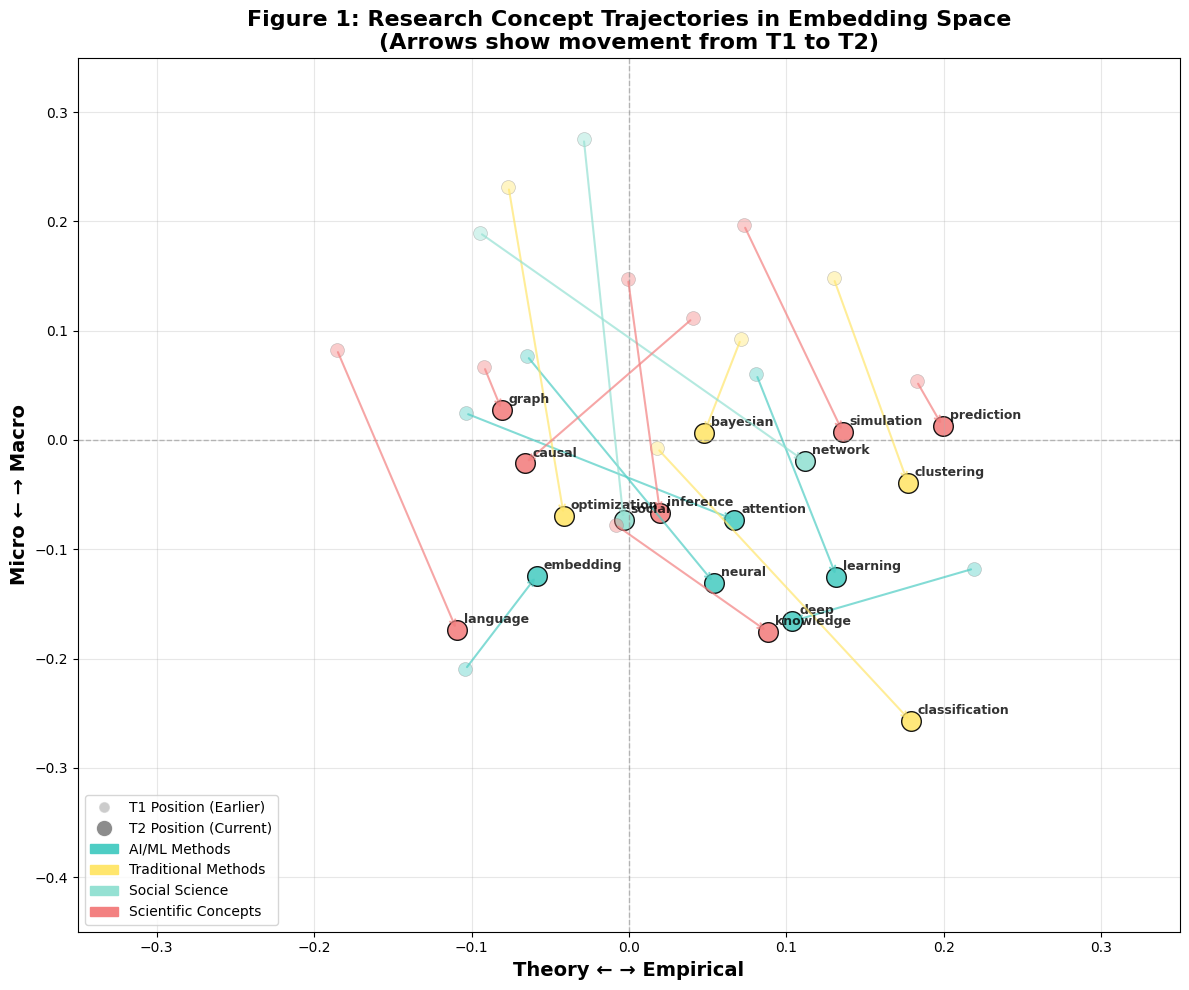

Figure 1 saved to: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_2/files/Kaggle/data/pilot_test/figure1_concept_trajectories.png


In [361]:
# Visualization - Recreate Figure 1 and Figure 2 from Memo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

# Load all required data
projection_df = pd.read_pickle(f'{pilot_dir}/projection_data.pkl')
matrix_data = pd.read_pickle(f'{pilot_dir}/distance_surprise_matrix.pkl')


# FIGURE 1: Research Concept Trajectories in Embedding Space
# X-axis: Theory ← → Empirical
# Y-axis: Micro ← → Macro
# Arrows show movement from T1 to T2


print("Creating Figure 1: Research Concept Trajectories in Embedding Space")

fig1, ax1 = plt.subplots(figsize=(12, 10))

# Select key concepts for visualization (avoid clutter)
key_concepts = [
    'neural', 'deep', 'learning', 'attention', 'embedding',
    'bayesian', 'classification', 'clustering', 'optimization',
    'social', 'network', 'simulation', 'causal', 'inference',
    'prediction', 'language', 'graph', 'knowledge'
]

# Filter to key concepts
viz_df = projection_df[projection_df['concept'].isin(key_concepts)].copy()

# Define colors for different concept categories
category_colors = {
    'AI/ML': '#4ECDC4',      # Teal
    'Traditional': '#FFE66D', # Yellow
    'Social': '#95E1D3',      # Light green
    'Scientific': '#F38181',  # Coral
}

def get_category(concept):
    if concept in ['neural', 'deep', 'learning', 'attention', 'embedding', 'adversarial', 'convolution']:
        return 'AI/ML'
    elif concept in ['bayesian', 'regression', 'classification', 'clustering', 'optimization']:
        return 'Traditional'
    elif concept in ['social', 'network', 'behavior', 'community', 'influence']:
        return 'Social'
    else:
        return 'Scientific'

viz_df['category'] = viz_df['concept'].apply(get_category)

# Plot trajectories (arrows from T1 to T2)
for _, row in viz_df.iterrows():
    color = category_colors[row['category']]

    # T1 position (lighter, smaller)
    ax1.scatter(row['theory_empirical_T1'], row['micro_macro_T1'],
                c=color, s=100, alpha=0.4, edgecolors='gray', linewidths=0.5)

    # T2 position (darker, larger)
    ax1.scatter(row['theory_empirical_T2'], row['micro_macro_T2'],
                c=color, s=200, alpha=0.9, edgecolors='black', linewidths=1)

    # Arrow from T1 to T2
    ax1.annotate('',
                 xy=(row['theory_empirical_T2'], row['micro_macro_T2']),
                 xytext=(row['theory_empirical_T1'], row['micro_macro_T1']),
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))

    # Label at T2 position
    ax1.annotate(row['concept'],
                 (row['theory_empirical_T2'], row['micro_macro_T2']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, fontweight='bold', alpha=0.8)

# Add axis lines at 0
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Labels and title
ax1.set_xlabel('Theory ← → Empirical', fontsize=14, fontweight='bold')
ax1.set_ylabel('Micro ← → Macro', fontsize=14, fontweight='bold')
ax1.set_title('Figure 1: Research Concept Trajectories in Embedding Space\n(Arrows show movement from T1 to T2)',
              fontsize=16, fontweight='bold')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, alpha=0.4, label='T1 Position (Earlier)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12, alpha=0.9, label='T2 Position (Current)'),
    mpatches.Patch(color='#4ECDC4', label='AI/ML Methods'),
    mpatches.Patch(color='#FFE66D', label='Traditional Methods'),
    mpatches.Patch(color='#95E1D3', label='Social Science'),
    mpatches.Patch(color='#F38181', label='Scientific Concepts'),
]
ax1.legend(handles=legend_elements, loc='lower left', fontsize=10)

ax1.set_xlim(-0.35, 0.35)
ax1.set_ylim(-0.45, 0.35)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{pilot_dir}/figure1_concept_trajectories.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure 1 saved to: {pilot_dir}/figure1_concept_trajectories.png")




Creating Figure 2: Distance × Surprise Matrix


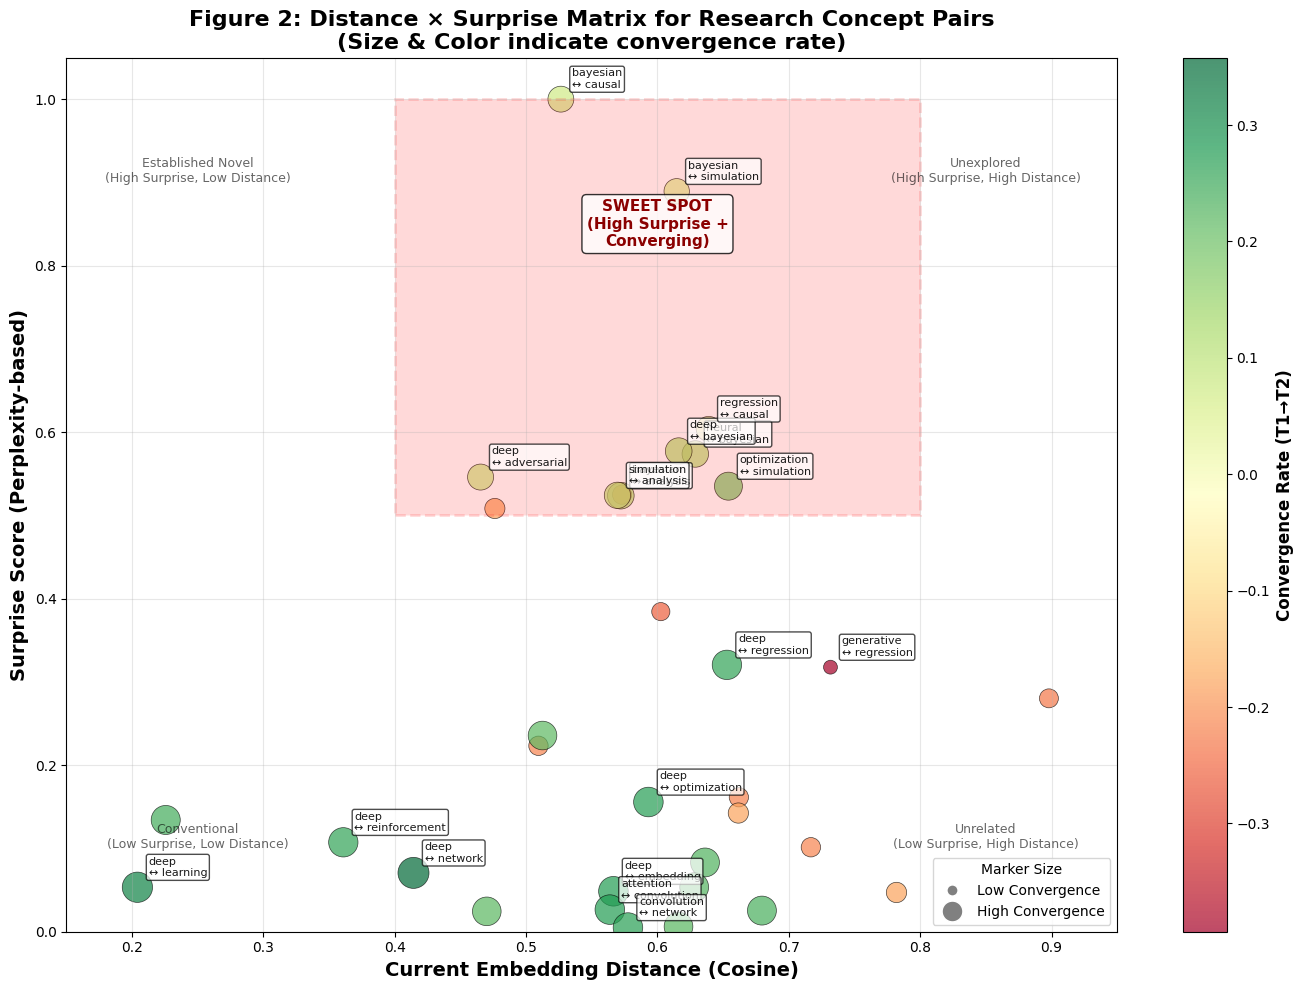

Figure 2 saved to: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_2/files/Kaggle/data/pilot_test/figure2_distance_surprise_matrix.png


In [367]:

# FIGURE 2: Distance × Surprise Matrix for Research Concept Pairs
# X-axis: Current Embedding Distance (Cosine)
# Y-axis: Surprise Score (Perplexity-based)
# Size & Color: Convergence Rate

print("\nCreating Figure 2: Distance × Surprise Matrix")

fig2, ax2 = plt.subplots(figsize=(14, 10))

# Select top pairs for visualization (avoid overplotting)
# Prioritize: sweet spot + top converging + top diverging
sweet_spot_pairs = matrix_data[matrix_data['quadrant'] == 'Sweet Spot']['pair'].tolist()
top_converging = matrix_data.nlargest(15, 'convergence')['pair'].tolist()
top_diverging = matrix_data.nsmallest(10, 'convergence')['pair'].tolist()
selected_pairs = list(set(sweet_spot_pairs + top_converging + top_diverging))

viz_matrix = matrix_data[matrix_data['pair'].isin(selected_pairs)].copy()

# Normalize convergence for size (make all positive for marker size)
viz_matrix['size'] = (viz_matrix['convergence'] - viz_matrix['convergence'].min()) / \
                     (viz_matrix['convergence'].max() - viz_matrix['convergence'].min())
viz_matrix['marker_size'] = 100 + viz_matrix['size'] * 400  # Scale between 100-500

# Plot scatter with color representing convergence rate
scatter = ax2.scatter(
    viz_matrix['current_distance'],
    viz_matrix['surprise'],
    c=viz_matrix['convergence'],
    s=viz_matrix['marker_size'],
    cmap='RdYlGn',  # Red (diverging) to Green (converging)
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Convergence Rate (T1→T2)', fontsize=12, fontweight='bold')

# Add "Sweet Spot" region highlight
sweet_spot_rect = mpatches.Rectangle(
    (0.4, 0.5), 0.4, 0.5,  # (x, y), width, height
    linewidth=2, edgecolor='red', facecolor='red', alpha=0.15,
    linestyle='--', label='Sweet Spot Region'
)
ax2.add_patch(sweet_spot_rect)

# Add text annotation for Sweet Spot
ax2.text(0.6, 0.85, 'SWEET SPOT\n(High Surprise +\nConverging)',
         fontsize=11, fontweight='bold', color='darkred',
         ha='center', va='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Label key points
for _, row in viz_matrix.iterrows():
    # Only label sweet spot and extreme points
    if row['quadrant'] == 'Sweet Spot' or row['convergence'] > 0.25 or row['convergence'] < -0.3:
        # Shorten pair name for readability
        short_name = row['pair'].replace(' ↔ ', '\n↔ ')
        ax2.annotate(short_name,
                     (row['current_distance'], row['surprise']),
                     xytext=(8, 8), textcoords='offset points',
                     fontsize=8, alpha=0.9,
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Add quadrant labels
ax2.text(0.25, 0.9, 'Established Novel\n(High Surprise, Low Distance)',
         fontsize=9, alpha=0.6, ha='center')
ax2.text(0.85, 0.9, 'Unexplored\n(High Surprise, High Distance)',
         fontsize=9, alpha=0.6, ha='center')
ax2.text(0.25, 0.1, 'Conventional\n(Low Surprise, Low Distance)',
         fontsize=9, alpha=0.6, ha='center')
ax2.text(0.85, 0.1, 'Unrelated\n(Low Surprise, High Distance)',
         fontsize=9, alpha=0.6, ha='center')

# Labels and title
ax2.set_xlabel('Current Embedding Distance (Cosine)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Surprise Score (Perplexity-based)', fontsize=14, fontweight='bold')
ax2.set_title('Figure 2: Distance × Surprise Matrix for Research Concept Pairs\n(Size & Color indicate convergence rate)',
              fontsize=16, fontweight='bold')

ax2.set_xlim(0.15, 0.95)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

# Add legend for marker size
size_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Low Convergence'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='High Convergence'),
]
ax2.legend(handles=size_legend, loc='lower right', fontsize=10, title='Marker Size')

plt.tight_layout()
plt.savefig(f'{pilot_dir}/figure2_distance_surprise_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure 2 saved to: {pilot_dir}/figure2_distance_surprise_matrix.png")

# Memo Pilot Test Report

## Research Question

How can we identify research domain combinations that are "converging" but remain underexplored, in order to predict research directions with transformative potential?

---

## Data and Methods

### Dataset
- **Source:** arXiv papers (Kaggle dataset from Cornell University)
- **Sample Size:** 30,000 randomly sampled papers
- **Time Range:** 2010-2024
- **Time Periods:** T1 (2010-2016) vs T2 (2017-2024)

### Methods Used

| Method | Purpose |
|--------|---------|
| Word2Vec (Skip-gram) | Train temporal embeddings |
| Procrustes Alignment | Align T1 and T2 embedding spaces |
| Kozlowski Dimension Projection | Project concepts onto Theory-Empirical and Micro-Macro axes |
| BERT Perplexity | Calculate surprise score for concept pairs |

### Key Parameters
- Word2Vec: vector_size=100, window=10, min_count=10, epochs=10
- Research concepts tracked: 30
- Concept pairs analyzed: 435

---

## Key Findings

### Concept Trajectories (Figure 1)

Most concepts moved toward **Empirical** and **Micro** directions from T1 to T2.

**Top movers toward Empirical:**
- network (Δ = +0.21)
- community (Δ = +0.18)
- attention (Δ = +0.17)

**Top movers toward Micro:**
- social (Δ = -0.35)
- optimization (Δ = -0.30)
- adversarial (Δ = -0.26)

This reflects the shift toward data-driven, individual-level analysis in modern research.

### Convergence Analysis

**Top Converging Pairs (concepts getting closer):**

| Pair | Convergence Rate | Distance T1 → T2 |
|------|------------------|------------------|
| deep ↔ network | +0.358 | 0.77 → 0.41 |
| deep ↔ learning | +0.314 | 0.52 → 0.20 |
| deep ↔ embedding | +0.274 | 0.84 → 0.57 |
| attention ↔ convolution | +0.273 | 0.84 → 0.56 |

**Top Diverging Pairs (concepts getting further apart):**

| Pair | Convergence Rate | Distance T1 → T2 |
|------|------------------|------------------|
| generative ↔ regression | -0.393 | 0.34 → 0.73 |
| reinforcement ↔ adversarial | -0.259 | 0.34 → 0.60 |

### Sweet Spot Candidates (Figure 2)

These pairs have **high surprise** (novel combination) and **positive convergence** (getting closer):

| Pair | Surprise | Convergence | Interpretation |
|------|----------|-------------|----------------|
| optimization ↔ simulation | 0.54 | +0.18 | Emerging optimization methods for simulation |
| deep ↔ bayesian | 0.58 | +0.11 | Bayesian deep learning frontier |
| bayesian ↔ analysis | 0.52 | +0.11 | Statistical foundations meeting data analysis |
| neural ↔ bayesian | 0.57 | +0.10 | Uncertainty quantification in neural networks |

These represent potentially **transformative research directions** that are currently underexplored but actively converging.

---

## Visualizations

### Figure 1: Concept Trajectories in Embedding Space

Arrows show how concepts moved from T1 (2010-2016) to T2 (2017-2024) along Theory-Empirical and Micro-Macro dimensions.

### Figure 2: Distance × Surprise Matrix

The red dashed region marks the "Sweet Spot" where high-surprise pairs are converging, indicating potential breakthrough areas.

---

## Implications for Chorus System

This pilot demonstrates that the proposed method can:

1. **Track semantic drift** of research concepts over time
2. **Identify converging pairs** that may represent emerging research trends
3. **Quantify novelty** using perplexity-based surprise scores
4. **Flag sweet spot candidates** for Chorus's "disrupting" function

For implementation in Chorus, this approach could periodically scan KnowledgeLab's knowledge base and recommend underexplored but converging research directions to researchers.

---

## Limitations

- Sample size (30k) is relatively small compared to full arXiv corpus
- Word2Vec captures limited context compared to transformer-based embeddings
- Perplexity from general BERT may not fully capture domain-specific surprise
- Only 30 concepts tracked, and could be expanded for broader coverage


<font color="purple">**Reminder:** To complete this week’s off-class work, please fill out the survey using the [link](https://forms.gle/N6wyqTxbzRWGTKtL7). Thank you for your feedback!</font>